In [1]:
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import numpy as np

# 1. MNIST 불러오기
mnist = fetch_openml('mnist_784', version=1, as_frame=False)
X = mnist.data          # (70000, 784)
y = mnist.target.astype(np.int64)

# 2. 픽셀값 정규화
X = X / 255.0

# 3. train / test 분리
# 원래 MNIST는 60000 / 10000으로 나누는 경우가 많지만
# 여기서는 간단히 train_test_split 사용
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=10000, random_state=42, stratify=y
)

# 4. kNN 모델 생성
# n_neighbors=k : 가까운 이웃 몇 개를 볼지
knn = KNeighborsClassifier(n_neighbors=3)

# 5. 학습
knn.fit(X_train, y_train)

# 6. 예측
y_pred = knn.predict(X_test)

# 7. 성능 평가
acc = accuracy_score(y_test, y_pred)
print("Accuracy:", acc)

Accuracy: 0.9735


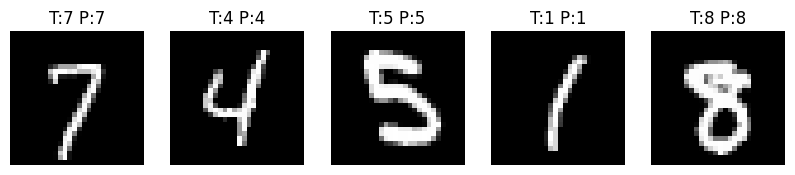

In [2]:
import matplotlib.pyplot as plt

# 테스트 샘플 5개 선택
num_samples = 5

plt.figure(figsize=(10,3))

for i in range(num_samples):
    img = X_test[i].reshape(28,28)
    true_label = y_test[i]
    pred_label = y_pred[i]
    
    plt.subplot(1, num_samples, i+1)
    plt.imshow(img, cmap='gray')
    plt.title(f"T:{true_label} P:{pred_label}")
    plt.axis('off')

plt.show()